## Name: Reem Alyahya

---
title: "Project 2: Student Exam Performance"
---


## Project Overview
  
This Project analyzes a dataset of students to find out what really affects their exam scores.

we are looking at everything that we think it affects to see what makes difference in students success.
## Objectives
  
  * Find the link between students behavior and their scores.
  * Discover which factors have the biggest impact.
  * Use statistics to check if some methods really help students to get better scores.
  * Provide recommendations for both students and teatchers.


## Project Scope:


### Import needed libraries

In [167]:
# Standard libraries
from pathlib import Path

# Installed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')
# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

### Data importing and reading

In [168]:
df = pd.read_csv('StudentPerformanceFactors.csv')
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


`Data is successfully loaded with 6607 rows and 20 columns that contains [Hours_Studied, Parental_Involvement, Previous_Scores, Exam_Score].`

In [169]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

### Findings:
* The DataFrame has some missing values in: `[Teacher_Quality, Parental_Education_Level, Distance_from_Home]` that need handling.
* The data is mixed of numerical and categorical variables.
* some columns are str based and will ned encoding.

-----

## Handling Missing Data(Data Cleaning):

Since the number of missing values  is quite small compared to the total dataset, we will fill them using the `mode()` method
**we chose the `mode()` method and not `mean()` because data types of the missing data is categorical and not numerical**

In [170]:

df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])

df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])

df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0])

#test if there are still missing values:

df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

## Findings:
After handling the missing values we performed a final test to ensure data consistency.
* Based on our test now we have zero missing data.
* the dataset is now ready to analyze.

---

## Descriptive Statistics:
To gain a better understanding fo our data distribution, we will apply descriptive statistics for all numerical columns.

In [171]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## Descriptive Statistics Findings:
* **Average Performance:** the mean exam score is approximately 67.24%, within a minimum score of 55% and maximum of 101% which needs to investigate why?
  * is it just a bonus
  * is it a data entry error?
* **Study Hours:** students study for 20 hours in average, but the minimum is one hour and the maximum as 44.
* **The std:** the `standard deviation` for Exam_score is 3.89 which indicating that the most students scores are around the mean.

### Let's see how many students have `Exam_Score` > 100

In [172]:
df[df['Exam_Score'] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


## Outlier Investigation:
After performing **`Descriptive Statistics`** on the DataFrame, we noticed an outlier in `Exam_Score` column with persentage of 101%.
We are between two decisions:
  1. drop the row.
  2. handle the score.
## Findings for this specific record:
  1. Attendance: 98% (above the average).
  2. Tutoring Sessions: 5 hours (way more than the average which is 1.49).
  3. Previous Score: 93 (high performance).
  4. Significant Study Time: 27 hours (Above the average).
  5. Sleep hours: 6 (average is 7)
## Decision
The result of 101 is more like to be bonus or a data entry error (101 insted of 100).
So the final decision is handling the value and not dropping the row.

## Handling the 101

In [173]:

df.loc[df['Exam_Score'] > 100, 'Exam_Score'] = 100
df['Exam_Score'].max()

np.int64(100)

-----

## Hypothesis Testing (Study Hours and Exam Score):
### Objective: To investigate if the amount of time spent studying influnces the final score or not.

* **Null Hypothesis ($H_0$):**

    There is no linear relationship between `Hours_Studied` and `Exam_Score` (r = 0).
* **Alternative Hypothesis ($H_a$):**

    There is a positive linear relationship between `Hours_Studied` and `Exam_Score` (r > 0).

## Visualizing Relationships:
To better understand how the variables interact we will use two types of visualizatons:
  1. **Heatmap:** This visualization gives an overview of the Pearson Correlation Cofficient (r) for all numerical variables.
  2. **Scatter Plot:** It focuses on our hypothesis , it visualizes the relationship between `Hours_Studied` and `Exam_Scores`

In [174]:
correlation = df.select_dtypes(include=['number']).corr()

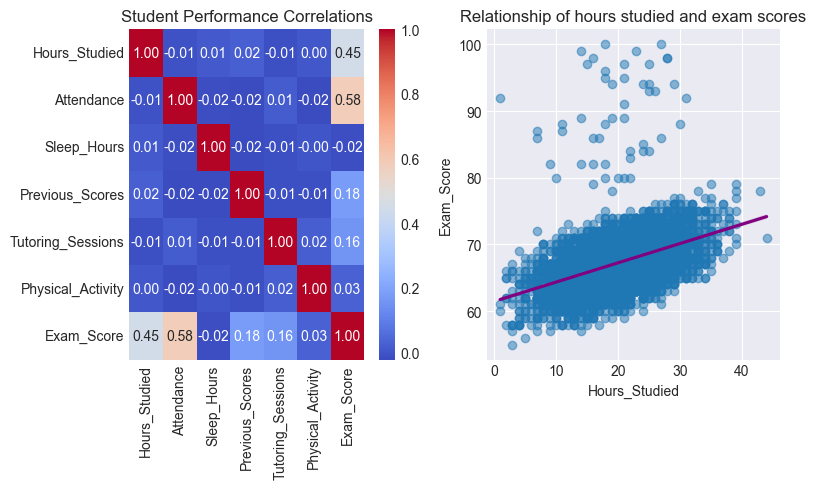

In [175]:
#Figures

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,5))

sns.heatmap(
correlation,
annot= True,
cmap= 'coolwarm',
fmt='.2f',
ax = ax1
)
ax1.set_title('Student Performance Correlations')

sns.regplot(
    data = df,
    x = 'Hours_Studied',
    y = 'Exam_Score',
    scatter_kws={
        'alpha': 0.5
        },
    line_kws={
        'color': 'purple'
    }
)
ax2.set_title('Relationship of hours studied and exam scores')
plt.tight_layout()
plt.show()



## Findings:
Since r = 0.45 we reject **Null Hypothesis ($H_0$):** and accept the **Alternative Hypothesis ($H_a$):**
There is a statistically significant positive relationship between study hours and exam scores, but there is other variable may play more importance role wich is `Attendnce` (r=0.58)


## Pearson Correlation Test:
   Since we want to find if the studied hours truly affects the exam scores or not, we will apply the Pearson Correlation Coefficient, to determine if correlation between Hours Studied and Exam Scores is statically significant.

In [176]:
alpha = 0.05

In [177]:

r_stat, p_value = pearsonr(df['Hours_Studied'], df['Exam_Score'])

print(p_value)
if p_value <= alpha:
    print("Conclusion: Studied hours has a significant effect on exam scores.")
else:
    print("Conclusion: not enough evidence to support the claim that Studied hours has a significant effect on exam scores.")


8.823e-320
Conclusion: Studied hours has a significant effect on exam scores.


### Findings:
After running `Pearsonr()` here is the outcomes:
* `p_value` = 8.823e-320 which is definitely less than `alpha`.
* Becuse `p_value` < `alpha` the correlation (r=0.45) is statistcally significant.

    `This proves the alternative hypothesis so we accept it and reject the null hypothesis`

---

## Hypothesis Testing (Attendance and Exam Score):
### Objective: To test if the frequency of attending classes has a statistically significant influnce on exame score.

* **Null Hypothesis ($H_0$):**

    There is no linear relationship between `Attendance` and `Exam_Score` (r = 0).
* **Alternative Hypothesis ($H_a$):**

    There is a significant positive linear relationship between `Attendance` and `Exam_Score` (r > 0).

## Visualizing Relationships:
To analyze how student attendance affects performance in exam we will use two visualization plots:
  1. **Scatter Plot:** to visualize the distribution of how student `Atendance` correlates with `Exam_Scores`.
  2. **Line plot:** To visualize the `Exam_Score` for `Attendance`.


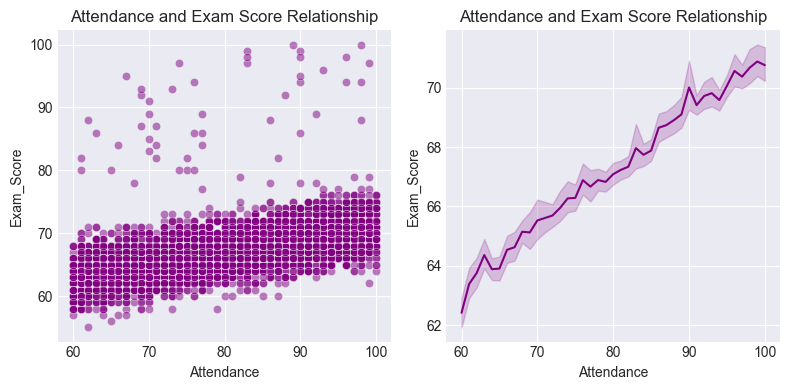

In [178]:
#

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))


sns.scatterplot(
    data = df,
    x = 'Attendance',
    y = 'Exam_Score',
    color = 'purple',
    alpha = 0.5,
    ax= ax1
)
ax1.set_title('Attendance and Exam Score Relationship')

sns.lineplot(
    data = df,
    x = 'Attendance',
    y = 'Exam_Score',
    color = 'purple',
    ax = ax2

)
ax2.set_title('Attendance and Exam Score Relationship')

plt.tight_layout()
plt.show()

## Findings:
Based on our data visualization we have two different outcomes:
1. **Scatter Plot( Shows every single student ):** we can see that as attendance goes up, the dots go higher, it clearly shows that exam scores affects by attendance.
2. **Lineplot:** By looking to the average score for each attendance level, the line goes up, proving that more attendance leads to better score in most cases.

## Pearson Correlation Test:
   Since we observed a strong connection in the charts, we need to prove it statically, we will use **Pearson Correlation Test** to to check if the relationship between the attendance frequency and exam score is real or not.

In [179]:

r_stat, p_value = pearsonr(df['Attendance'], df['Exam_Score'])

print(p_value)
if p_value <= alpha:
    print("Conclusion: Attendance Frequency has a significant effect on exam scores.")
else:
    print("Conclusion: not enough evidence to support the claim that Attendance Frequency has a significant effect on exam scores.")


0.0
Conclusion: Attendance Frequency has a significant effect on exam scores.


### Findings:
After running `Pearsonr()` here is the outcomes:
* Corelation Coefficient(r): 0.58 (Positive relationship)
* `p_value` = 0.0 which is definitely less than `alpha`.

    `This proves the alternative hypothesis so we accept it and reject the null hypothesis`

---

## Hypothesis Testing (Tutoring Sessions and Exam Score):
### Objective: To test if the number of Tutoring Sessions has a statistically significant influnce on exame score.

* **Null Hypothesis ($H_0$):**

    There is no relationship between `Tutoring_Sessions` and `Exam_Score`
* **Alternative Hypothesis ($H_a$):**

    There is a significant affect between`Tutoring_Sessions` and `Exam_Score`.

## Visualizing Relationships:
To analyze how Tutoring_Sessions affects performance in exam we will use two visualization plots:
  1. **Violin plot:** to visulize the distribution and probabillity of `Exam_Score` across different hours of `Tutoring_Sessions`.
  2. **Bar plot:** To visualize the average `Exam_Score` for each `Tutoring_Sessions`.


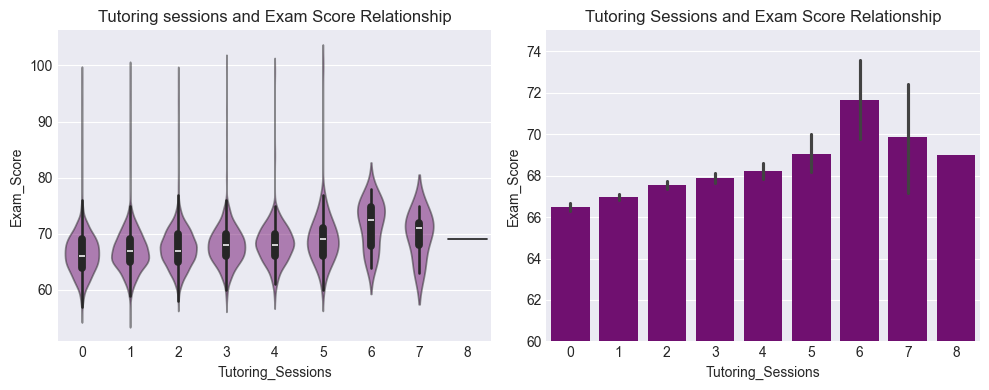

In [180]:
#

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))


sns.violinplot(
    data = df,
    x = 'Tutoring_Sessions',
    y = 'Exam_Score',
    color = 'purple',
    alpha = 0.5,
    ax= ax1
)
ax1.set_title('Tutoring sessions and Exam Score Relationship')

sns.barplot(
    data = df,
    x = 'Tutoring_Sessions',
    y = 'Exam_Score',
    color = 'purple',
    ax = ax2

)
plt.ylim(60, 75)
ax2.set_title('Tutoring Sessions and Exam Score Relationship')

plt.tight_layout()
plt.show()

## Findings:
By analyzing the **Violin plot** and **Bar plot** for `Tutoring_Sessions`, we can see the following:
* **Positive trend:** The bar plot shows that average exam scores increases as students attend more tutoring sessions up until 6.

* **Score distribution:** The violin plot shows that most students scores are around (65-70), but it goes higher for the students whom attended 6 sessions.

* Why does the trend change after 6?
   - *Fewer Students*: Very few student in our data attended more than 6 sessions, for example only one person attended 8 sessions, 7 attended 7.
   
   - *Error Bars*: The black error bars became longer for 6 and 7 sessions because of the small samples size.

In [181]:
df['Tutoring_Sessions'].value_counts().sort_index()

Tutoring_Sessions
0    1513
1    2179
2    1649
3     836
4     301
5     103
6      18
7       7
8       1
Name: count, dtype: int64

## Spearman Correlation Test:
   Since we observed a strong connection in the charts, we need to prove it statically, we will use **Spearman Correlation Test** to to check if the relationship between the Tutoring Sessions and Exam scores is significant or not.

In [183]:

rho, p_value = stats.spearmanr(df['Tutoring_Sessions'], df['Exam_Score'])

print(p_value)
if p_value <= alpha:
    print("Conclusion: Tutoring Sessions count has a significant effect on exam scores.")
else:
    print("Conclusion: not enough evidence to support the claim that Tutoring Sessions count has a significant effect on exam scores.")


5.012970926747344e-41
Conclusion: Tutoring Sessions count has a significant effect on exam scores.


### Findings:
After running `spearmanr()` test, here are the outcomes:
* `p_value` = 5.012970926747344e-41 which is definitely less than `alpha`.
* There is a statistically significant relationship between `Tutoring_Sessions` and `Exam_Score`.

    `This proves the alternative hypothesis so we accept it and reject the null hypothesis`

---